# Notebook 02 — Análisis Exploratorio de Datos (EDA)

Comprende los datos, justifica la selección de covariables del propensity score y documenta las particularidades del dataset para el TFG escrito.

Incluye explícitamente la **inversión de signo del SMS** (sección 4): los receptores de SMS muestran no-asistencia más alta sin ajustar — sesgo de selección, no efecto perjudicial — y constituye la motivación cualitativa del IPW que se estima en el NB04.

In [1]:
# Imports y configuración global
from __future__ import annotations

import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Permitir importar el paquete src/ desde el notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import eda
from src.rutas import (
    CSV_FULL_CLEAN,
    FIGURAS,
    REPORTES,
    SEED,
)

# Logging hacia stdout para que las cabeceras informativas aparezcan
# en las celdas del notebook.
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    stream=sys.stdout,
    force=True,
)

# Semilla global (NB02 no es estocástico, pero fija convención del proyecto).
np.random.seed(SEED)

FIGURAS.mkdir(parents=True, exist_ok=True)
REPORTES.mkdir(parents=True, exist_ok=True)

# Estilo común para todas las figuras del notebook
eda.configurar_estilo()

# Cargamos el dataset limpio (output de NB01) y normalizamos las columnas
# binarias que pd.read_csv interpreta como bool — las queremos como int
# para que groupbys y .loc[0]/.loc[1] funcionen como en NB01.
df = pd.read_csv(
    CSV_FULL_CLEAN,
    parse_dates=["ScheduledDay", "AppointmentDay"],
)
df = eda.normalizar_binarios(df)

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas".replace(",", "."))
print(f"Columnas disponibles: {sorted(df.columns)}")


Columnas binarias normalizadas a int: ['SMS_received', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']


Dataset cargado: 106.987 filas × 28 columnas
Columnas disponibles: ['Age', 'Alcoholism', 'AppointmentDay', 'AppointmentID', 'Date.diff', 'Diabetes', 'Gender', 'Handcap', 'Hipertension', 'Neighbourhood', 'PatientId', 'SMS_received', 'ScheduledDay', 'Scholarship', 'Showed_up', 'age_band', 'appointment_month', 'appointment_weekday', 'chronic_flag', 'comorbidity_count', 'is_first_visit', 'lead_time', 'lead_time_bin', 'neighbourhood_encoded', 'prior_appointment_count', 'prior_noshow_rate', 'scheduled_month', 'scheduled_weekday']


## 1. Tasa de no-asistencia global y por variables clave

**Lo que muestra esta sección:** la tasa de no-show del dataset completo y su descomposición por las variables candidatas a covariables del propensity score.

**Interpretación:** descriptiva. Una variable con tasa de no-show muy distinta entre niveles indica que está asociada al outcome — esto no implica nada causal todavía. La covariable entra al propensity score en NB04 sólo si además está asociada al tratamiento (SMS), criterio que se evalúa en la matriz de correlación de la sección 2.

Se incluye `SMS_received` como variable descriptiva, **sin interpretación causal** — el sentido del efecto se trata explícitamente en la sección 4.

> Nota sobre el día de la semana: la clínica del dataset no opera en domingo (0 citas) y opera marginalmente en sábado, por lo que el panel muestra lunes–sábado. La lista exacta de días presentes queda registrada en el sidecar JSON (`dias_semana_presentes`) para citarse en la sección de datos del TFG escrito.

Tasa global: 106987 filas → 85307 asistieron (79.74%), 21680 no-show (20.26%)



--- Tasa de no-show por lead_time_bin ---
                   n  pct_asistio  pct_noshow
lead_time_bin                                
mismo_dia      37159       0.9530      0.0470
1-7d           31446       0.7589      0.2411
8-14d          11644       0.6948      0.3052
15+d           26738       0.6710      0.3290

--- Tasa de no-show por age_band ---
              n  pct_asistio  pct_noshow
age_band                                
0-18      25327       0.7746      0.2254
19-35     24137       0.7617      0.2383
36-55     30019       0.8029      0.1971
56-70     18931       0.8444      0.1556
70+        8573       0.8416      0.1584

--- Tasa de no-show por appointment_weekday ---
                         n  pct_asistio  pct_noshow
appointment_weekday                                
0                    21903       0.7939      0.2061
1                    24831       0.7977      0.2023
2                    25090       0.8028      0.1972
3                    16659       0.8053      0.

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_noshow_por_variables_v1.png


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_noshow_top20_barrios_v1.png


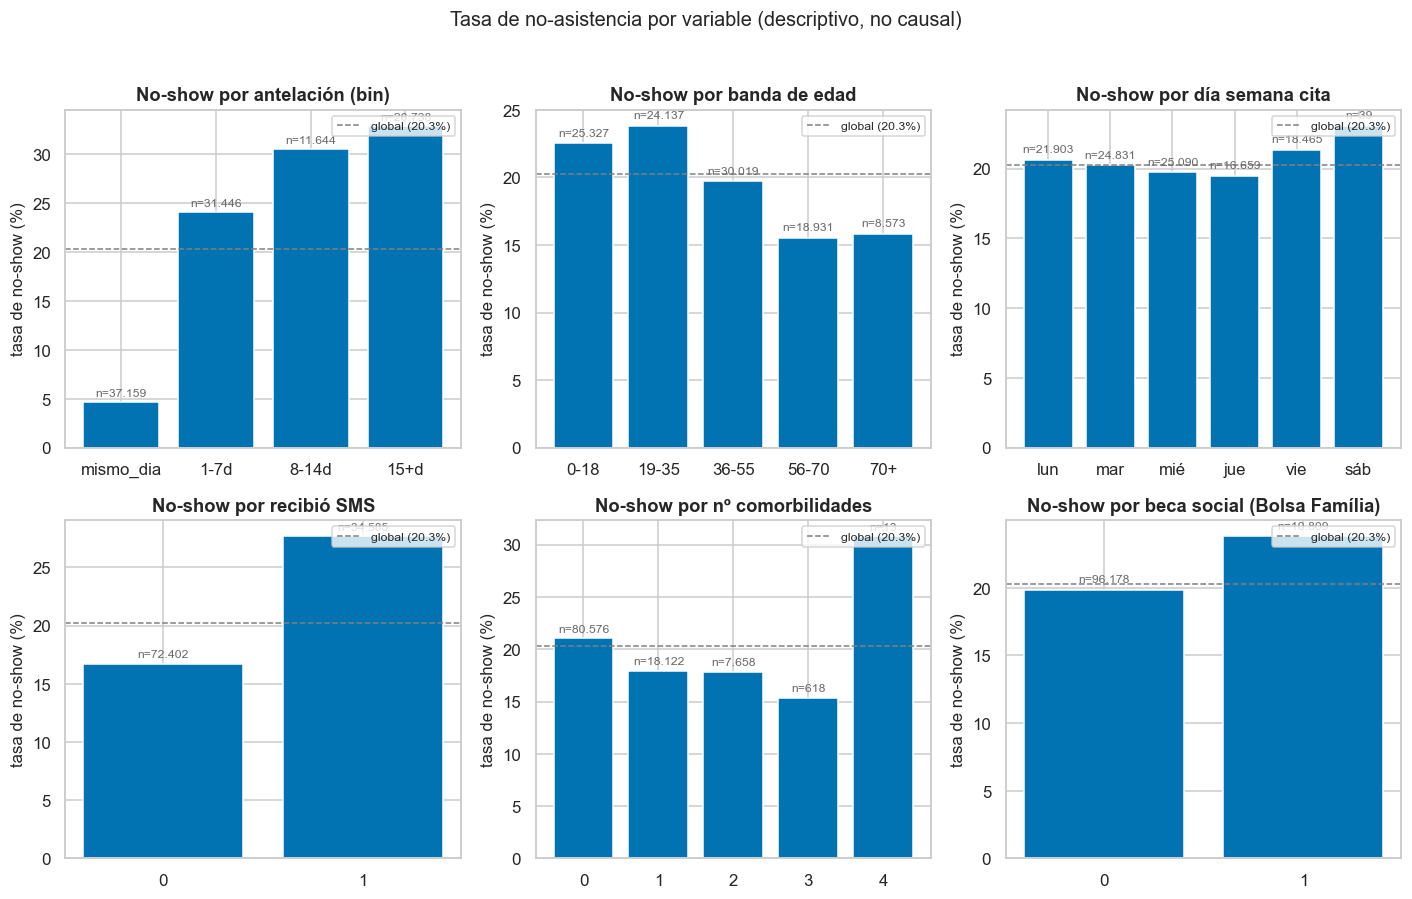

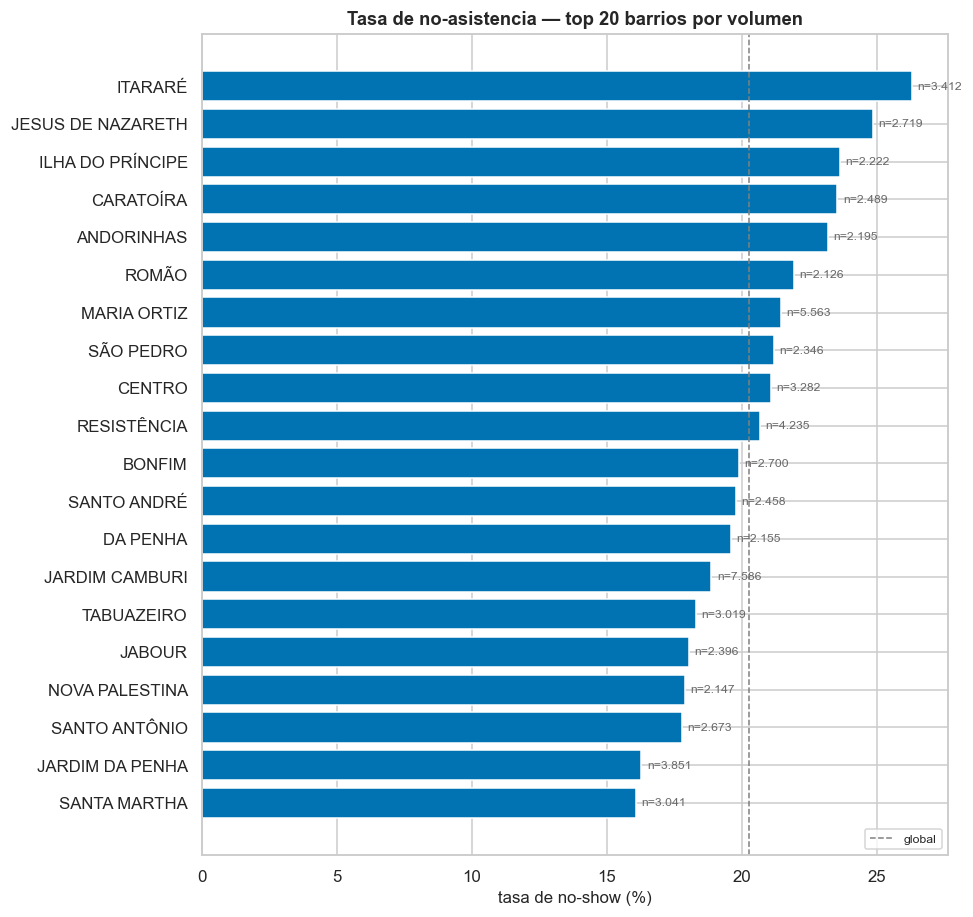

In [2]:
# Tasa global
info_global = eda.tasa_noshow_global(df)

# Tablas numéricas por variable (las imprimimos antes que las figuras
# para que la narrativa textual del TFG escrito tenga referencia directa)
for var in ["lead_time_bin", "age_band", "appointment_weekday",
            "SMS_received", "comorbidity_count", "Scholarship"]:
    print(f"\n--- Tasa de no-show por {var} ---")
    tabla = eda.tasa_noshow_por_variable(
        df, var,
        orden={
            "lead_time_bin": ["mismo_dia", "1-7d", "8-14d", "15+d"],
            "age_band": ["0-18", "19-35", "36-55", "56-70", "70+"],
        }.get(var),
    )
    print(tabla.round(4).to_string())

# Panel multi-variable (figura A)
ruta_panel = eda.plot_tasa_noshow_panel(df, FIGURAS / "nb02_noshow_por_variables_v1.png")

# Top-20 barrios (figura B)
ruta_barrios = eda.plot_noshow_top_barrios(
    df, FIGURAS / "nb02_noshow_top20_barrios_v1.png", n_top=20,
)


## 2. Matriz de correlación — justificación de la selección de covariables del IPW

**Objetivo:** identificar qué variables están asociadas simultáneamente a `Showed_up` (outcome) y a `SMS_received` (tratamiento). Esas variables son los confounders críticos que el propensity score del NB04 debe ajustar.

- Correlaciones de Pearson sobre el conjunto modelable. Los coeficientes mezclan dos casos especiales —**phi** (binaria-binaria) y **point-biserial** (binaria-continua)— pero ambos son casos particulares de Pearson y comparables en magnitud relativa, por lo que la matriz se interpreta en bloque sin distinción.
- `prior_noshow_rate` es `NaN` en las primeras visitas (~72% del dataset). Pandas computa correlaciones pairwise por defecto, de modo que las celdas que involucran esta variable se calculan sobre el subconjunto de visitas repetidas. El recuento exacto queda persistido en el sidecar (`n_prior_noshow_rate_no_nulos`) y se cita como caveat en la sección de metodología del TFG.
- **No es una afirmación causal**: la matriz justifica la elección de covariables, no el efecto.

Top 8 correlaciones con Showed_up (por magnitud):
lead_time                 -0.1857
scheduled_month            0.1602
SMS_received              -0.1273
prior_noshow_rate         -0.1203
Age                        0.0670
is_first_visit            -0.0620
prior_appointment_count    0.0458
Hipertension               0.0373

Top 8 correlaciones con SMS_received (por magnitud):
lead_time                  0.3965
scheduled_month           -0.2928
Showed_up                 -0.1273
appointment_month          0.1087
is_first_visit             0.1025
appointment_weekday       -0.0926
scheduled_weekday          0.0786
prior_appointment_count   -0.0764
Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_correlacion_heatmap_v1.png


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_correlaciones_dual_v1.png


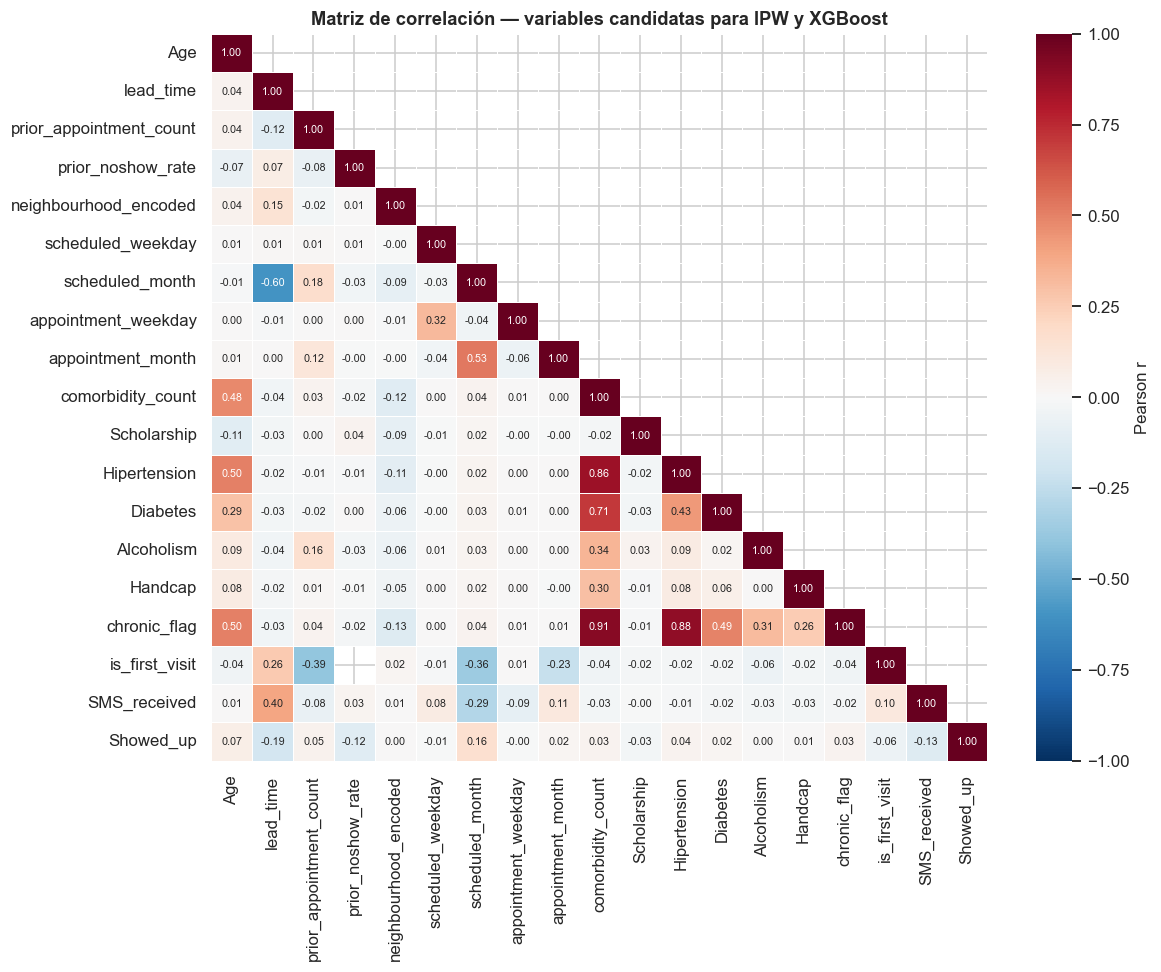

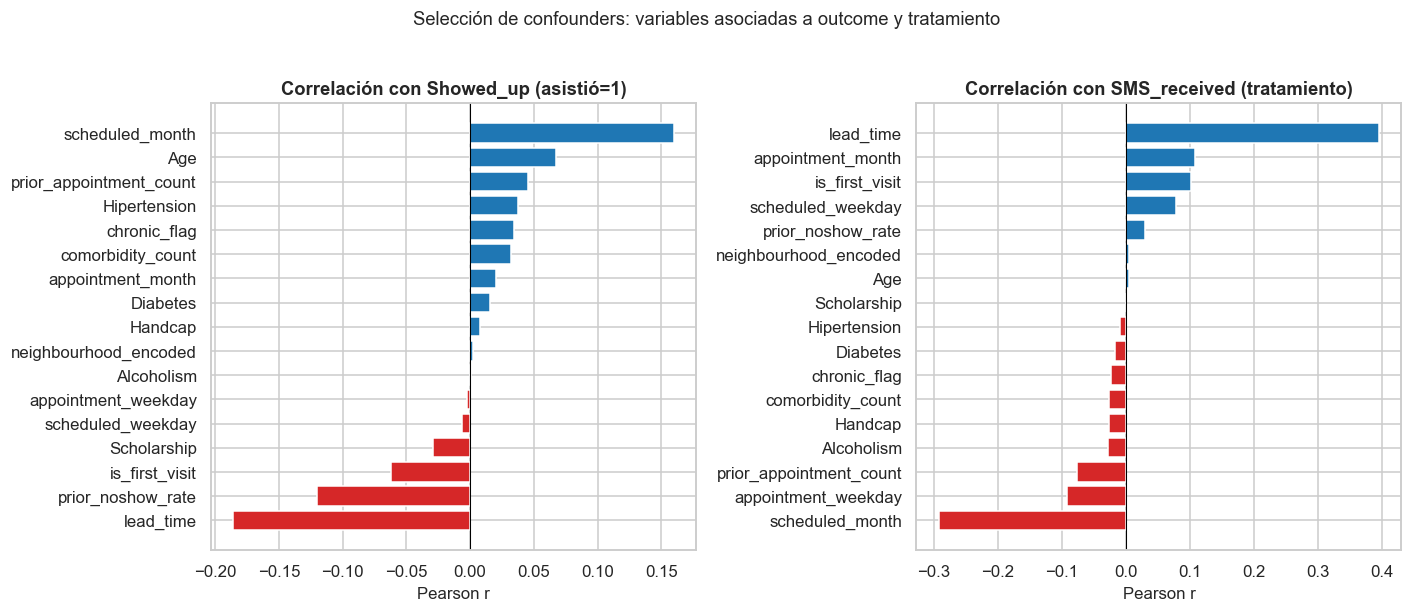

In [3]:
# Matriz de correlación completa
corr = eda.matriz_correlacion(df)

# Top correlaciones con outcome y con tratamiento (informativas)
corr_outcome = corr["Showed_up"].drop("Showed_up").sort_values(key=lambda s: s.abs(), ascending=False)
corr_tratamiento = corr["SMS_received"].drop("SMS_received").sort_values(key=lambda s: s.abs(), ascending=False)

print("Top 8 correlaciones con Showed_up (por magnitud):")
print(corr_outcome.head(8).round(4).to_string())
print("\nTop 8 correlaciones con SMS_received (por magnitud):")
print(corr_tratamiento.head(8).round(4).to_string())

# Figura: heatmap (figura C)
ruta_heatmap = eda.plot_correlacion_heatmap(corr, FIGURAS / "nb02_correlacion_heatmap_v1.png")

# Figura: barras lado-a-lado outcome vs tratamiento (figura D)
ruta_dual = eda.plot_correlaciones_dual(corr, FIGURAS / "nb02_correlaciones_dual_v1.png")


## 3. ¿Quién recibe SMS? — análisis de la asignación del tratamiento

**Idea:** si el SMS estuviera asignado aleatoriamente, su proporción sería constante entre subgrupos. La presencia de variación sistemática (por edad, antelación, barrio, condición socioeconómica) es la **evidencia descriptiva** de que la comparación ingenua SMS=1 vs SMS=0 está sesgada — y por tanto la base de la motivación cualitativa del IPW.

Ojo: lo que importa para confounding es que la covariable se asocie *al mismo tiempo* a la asistencia y al SMS — eso ya está cuantificado en la sección 2. Aquí lo visualizamos para que la sección de metodología del TFG escrito pueda anclar la narrativa en cifras concretas.

% SMS global = 32.33%

--- % SMS por age_band ---


              n  pct_sms
age_band                
0-18      25327   0.2982
19-35     24137   0.3439
36-55     30019   0.3336
56-70     18931   0.3331
70+        8573   0.2813

--- % SMS por lead_time_bin ---
                   n  pct_sms
lead_time_bin                
mismo_dia      37159   0.0000
1-7d           31446   0.3617
8-14d          11644   0.5868
15+d           26738   0.6126

--- % SMS por Scholarship ---
                 n  pct_sms
Scholarship                
0            96178   0.3233
1            10809   0.3232

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_sms_asignacion_v1.png


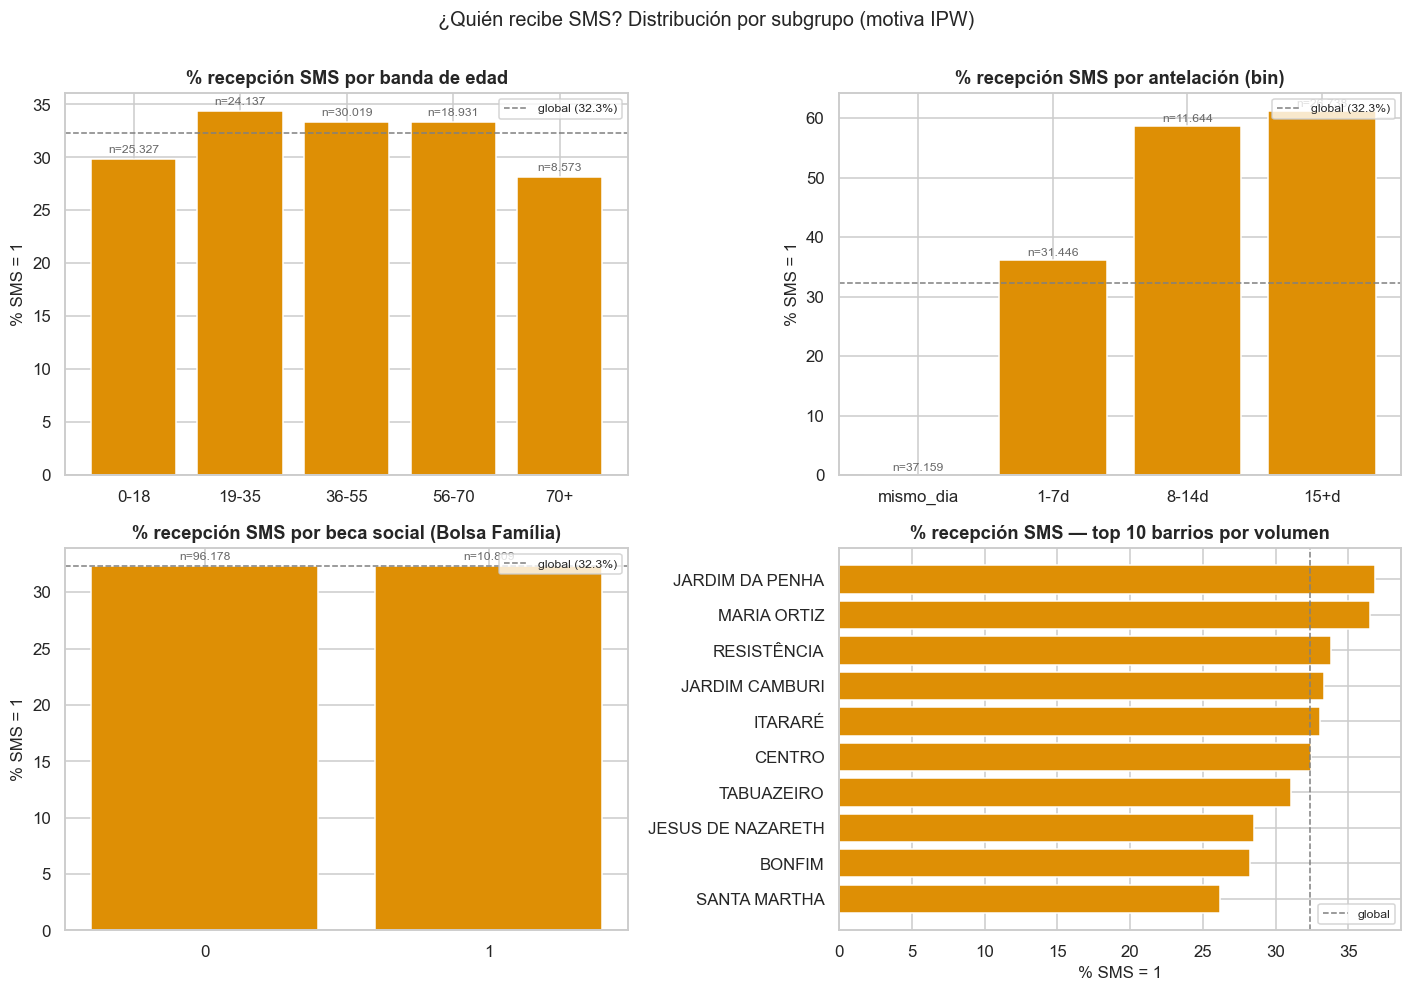

In [4]:
# Tablas numéricas: % SMS por subgrupo
print(f"% SMS global = {100 * df['SMS_received'].mean():.2f}%\n")

ordenes = {
    "lead_time_bin": ["mismo_dia", "1-7d", "8-14d", "15+d"],
    "age_band": ["0-18", "19-35", "36-55", "56-70", "70+"],
}
for var in ["age_band", "lead_time_bin", "Scholarship"]:
    print(f"--- % SMS por {var} ---")
    print(eda.tasa_sms_por_variable(df, var, orden=ordenes.get(var)).round(4).to_string())
    print()

# Figura E: panel 2x2 (age_band, lead_time_bin, Scholarship, top-10 barrios)
ruta_sms = eda.plot_distribucion_sms(df, FIGURAS / "nb02_sms_asignacion_v1.png")


## 4. Inversión de signo del SMS — el hallazgo que motiva toda la metodología

Este es uno de los hallazgos a **dejar absolutamente claro** en el TFG escrito y en la defensa oral.

Cuando se calcula la tasa de no-asistencia **sin ajustar**, los pacientes que recibieron SMS no-show *más* que los que no lo recibieron. La intuición ingenua diría que el SMS empeora la asistencia. Eso no es lo que está pasando:

- El SMS se enviaba con mayor probabilidad a citas de **mayor antelación** (`lead_time`), donde el no-show es estructuralmente más alto independientemente del SMS (ver sección 2).
- El SMS también se enviaba con mayor probabilidad a algunos barrios y bandas de edad sistemáticamente diferentes (ver sección 3).
- Esos perfiles eran más propensos a no asistir *por razones distintas al SMS*. **El SMS está sistemáticamente asignado a perfiles de mayor riesgo basal — no lo causa.**

La comparación cruda mezcla el efecto del SMS con el del perfil del receptor → estimación causal sesgada. **Para aislar el efecto causal del SMS hay que reponderar la muestra de modo que los dos brazos sean comparables en covariables observables** → IPW estabilizado en NB04.

Si esta inversión sorprende durante la defensa sin preparación, parece un error de modelado. Anticipándola aquí como motivación cualitativa, se convierte en la mejor justificación posible de toda la cadena metodológica.

Tasas no-show sin ajustar: SMS=0 → 16.73%, SMS=1 → 27.67% (Δ = +10.94 pp)


Inversión de signo CONFIRMADA: los receptores de SMS no asisten MÁS sin ajustar. Esto es sesgo de selección, no efecto causal — documentado en NB02 §4 como motivación cualitativa de IPW.



Nº SMS=0: 72.402
Nº SMS=1: 34.585
% no-show SMS=0: 16.73%
% no-show SMS=1: 27.67%
Δ (SMS=1 − SMS=0): +10.94 pp
Tasas no-show sin ajustar: SMS=0 → 16.73%, SMS=1 → 27.67% (Δ = +10.94 pp)


Inversión de signo CONFIRMADA: los receptores de SMS no asisten MÁS sin ajustar. Esto es sesgo de selección, no efecto causal — documentado en NB02 §4 como motivación cualitativa de IPW.


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_inversion_signo_sms_v1.png


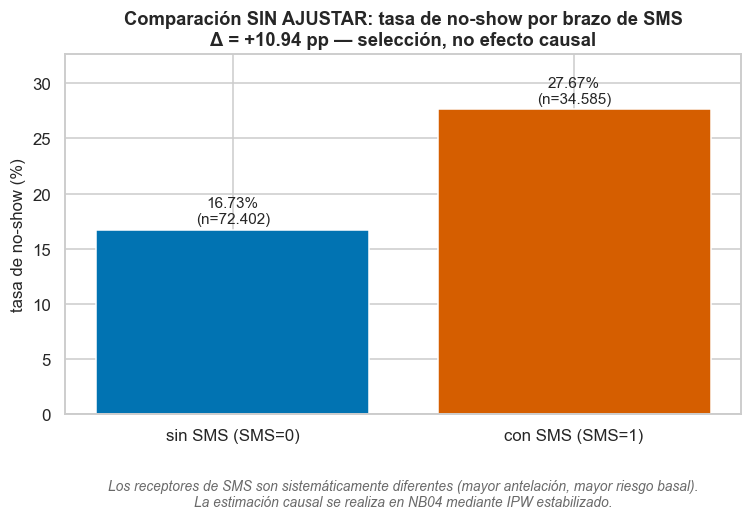

In [5]:
# Cifras crudas para el TFG escrito (sin ajustar — descriptivas)
info_inversion = eda.inversion_signo_sms(df)
print(f"\nNº SMS=0: {info_inversion['n_sms0']:,}".replace(",", "."))
print(f"Nº SMS=1: {info_inversion['n_sms1']:,}".replace(",", "."))
print(f"% no-show SMS=0: {100 * info_inversion['pct_noshow_sms0']:.2f}%")
print(f"% no-show SMS=1: {100 * info_inversion['pct_noshow_sms1']:.2f}%")
print(f"Δ (SMS=1 − SMS=0): {100 * info_inversion['diff_pp_sms1_menos_sms0']:+.2f} pp")

# Figura F: dos barras con anotaciones explicativas
ruta_inversion = eda.plot_inversion_signo_sms(
    df, FIGURAS / "nb02_inversion_signo_sms_v1.png",
)


## 5. Distribución del lead_time y valores extremos

`lead_time` (días entre programación y cita) es, según la literatura y los primeros indicios de las secciones anteriores, **el predictor más fuerte de no-show**. Aquí se documenta:

- Forma de la distribución (muy asimétrica a la derecha, masa concentrada en bookings del mismo día y de 1–7 días).
- Valores extremos: pocas filas con `lead_time` negativo (anomalía documentada en NB01) y una cola larga de citas a >100 días.
- Relación monotónica entre antelación y tasa de no-show por día, restringida a tramos con soporte muestral suficiente (n≥200 por día) para evitar interpretar ruido en la cola.

Estos números entran tanto en la sección de datos del TFG como en la justificación de incorporar **términos cuadráticos / B-splines** en el propensity score de NB04 para variables continuas.

Resumen de lead_time (días):
            n_negativo: 5
           n_mismo_dia: 37154
         pct_mismo_dia: 0.3472758372512548
               mediana: 4.0
                 media: 10.166721190425005
                   p90: 29.0
                   p99: 69.0
                maximo: 179


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_lead_time_distribucion_v1.png


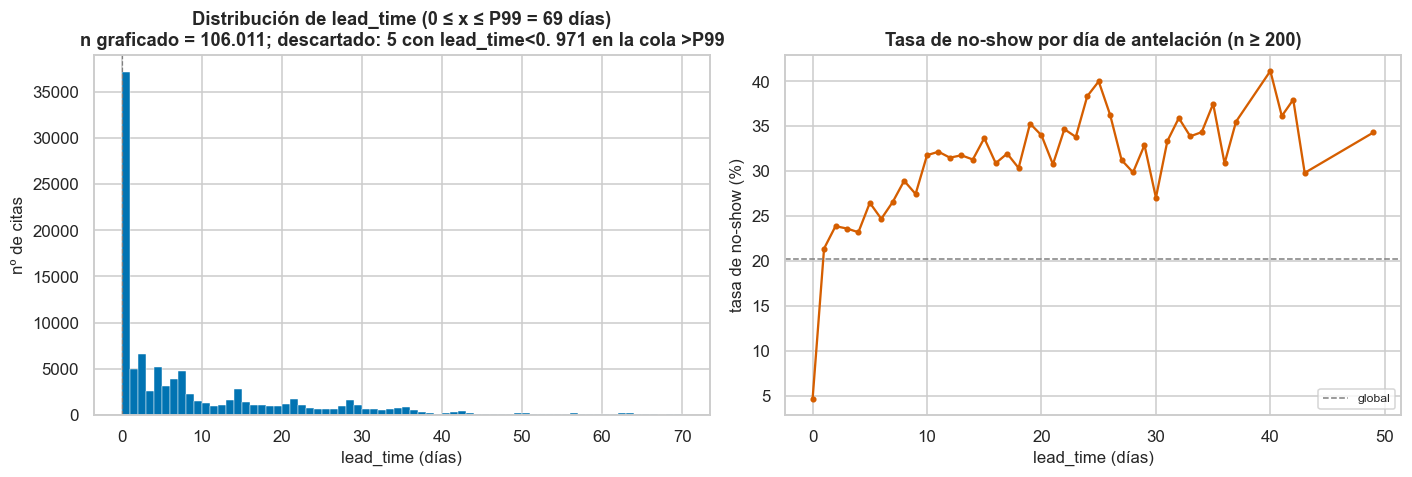

In [6]:
# Estadísticas y plot del lead_time
info_lead_time = eda.resumen_lead_time(df)
print("Resumen de lead_time (días):")
for k, v in info_lead_time.items():
    print(f"  {k:>20s}: {v}")

ruta_lt = eda.plot_distribucion_lead_time(
    df, FIGURAS / "nb02_lead_time_distribucion_v1.png",
)


## 6. Análisis a nivel paciente — repetición y primera visita

El dataset es **observacional con pacientes que reaparecen**. Esto tiene tres consecuencias metodológicas:

1. **Dependencia intra-paciente**: las observaciones no son i.i.d., lo que justifica el **bootstrap por clúster (PatientId)** del NB04 paso 9.
2. **El partido aleatorio sería tramposo**: separar aleatoriamente exposiciones del mismo paciente entre train y test contaminaría el modelo predictivo. NB01 usa partición temporal precisamente por esto.
3. **Tasa de no-show diferencial primera-vs-repetida**: si las primeras visitas tienen una tasa marcadamente distinta, `is_first_visit` es un confounder candidato que ya entra en el propensity score y en el modelo de XGBoost.

> **Caveat — censura por la izquierda.** `is_first_visit` se construye con la regla estricta de tiempo de decisión sobre la ventana temporal del dataset (~6 semanas de citas). Debe interpretarse como *"primera visita observada"* o *"ausencia de historial previo observado"*, **no** como garantía de que el paciente nunca acudió antes a la clínica. Idéntico cuidado con `prior_appointment_count` y `prior_noshow_rate`: resumen sólo el historial visible. Esta limitación se cita textualmente como **censura por la izquierda** en la sección de limitaciones del TFG escrito y se mantendrá presente al interpretar la diferencia de no-show primera-vs-repetida — parte de esa diferencia puede deberse a que las visitas etiquetadas como "primeras" mezclan a pacientes realmente nuevos con pacientes con historial previo no observado.

Resumen a nivel paciente:
                n_pacientes_unicos: 60.270
          media_citas_por_paciente: 1.7751
        mediana_citas_por_paciente: 1.0000
            p95_citas_por_paciente: 4.0000
            max_citas_por_paciente: 88
       pct_pacientes_una_sola_cita: 0.6114
           noshow_primeras_visitas: 0.2182
                  noshow_repetidas: 0.1627
    diff_pp_primera_menos_repetida: 0.0555


Figura guardada: /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb02_pacientes_distribucion_v1.png


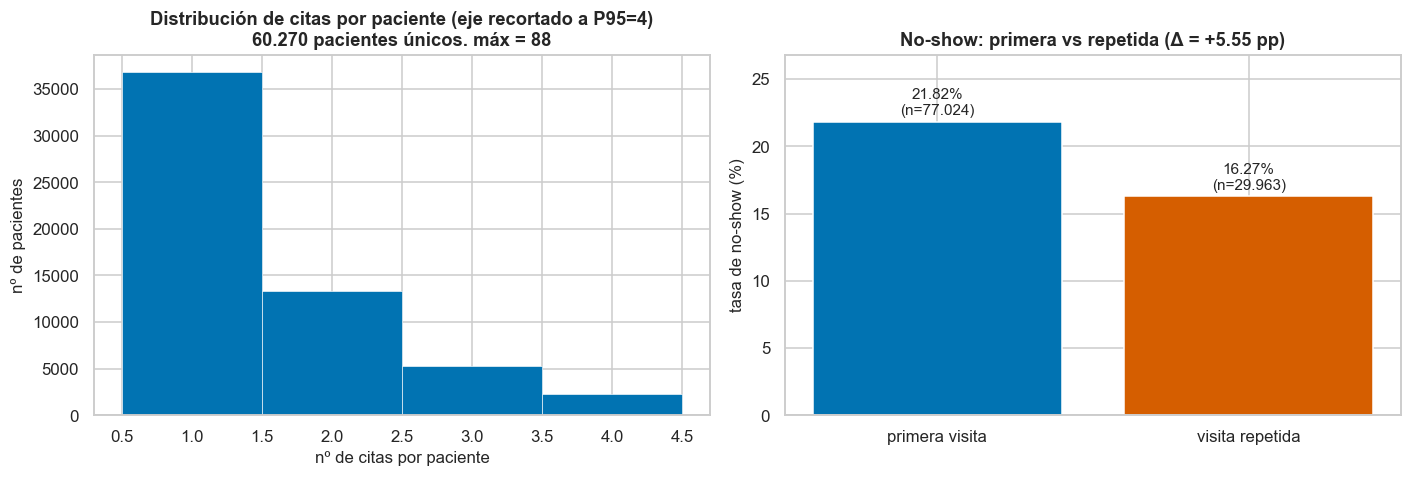

In [7]:
info_pacientes = eda.estadisticas_pacientes(df)
print("Resumen a nivel paciente:")
for k, v in info_pacientes.items():
    if isinstance(v, float):
        print(f"  {k:>32s}: {v:.4f}")
    else:
        print(f"  {k:>32s}: {v:,}".replace(",", "."))

ruta_pac = eda.plot_analisis_pacientes(
    df, FIGURAS / "nb02_pacientes_distribucion_v1.png",
)


## 7. Quirks documentados + persistencia de metadatos

Hallazgos a citar en la sección de datos / limitaciones del TFG:

- `lead_time < 0` (5 filas): documentadas en NB01 como anomalías del sistema de citación. Tratadas operativamente como booking de mismo día.
- `prior_noshow_rate` es `NaN` para las primeras visitas (~72%) por construcción de la regla estricta de tiempo de decisión. Los modelos aguas abajo deben tener una política explícita (e.g., imputación a 0 con flag, o `XGBoost` que admite NaN nativo).
- `scheduled_hour` constante a 0 → eliminada en NB01.
- `Handcap` resultó binaria en este CSV → no requiere recodificación.
- `Neighbourhood` con 81 niveles → frequency encoding, **nunca** target encoding (evita filtrar el outcome al modelo).

Persistimos los números clave en un sidecar JSON para alimentar la redacción del TFG y para que el experimento sea reproducible meses después.

In [8]:
# Top-5 correlaciones por magnitud para el sidecar (informativo)
top_outcome = corr_outcome.head(5).to_dict()
top_trat = corr_tratamiento.head(5).to_dict()

metadatos = eda.escribir_metadatos_nb02(
    REPORTES / "nb02_metadatos_v1.json",
    df=df,
    info_global=info_global,
    info_inversion=info_inversion,
    info_lead_time=info_lead_time,
    info_pacientes=info_pacientes,
    top_corr_outcome=top_outcome,
    top_corr_tratamiento=top_trat,
)

print("\nMetadatos NB02 persistidos. Resumen ejecutivo:")
print(f"  Tasa no-show global       : {100 * metadatos['pct_noshow_global']:.2f}%")
print(f"  Δ no-show (SMS=1 − SMS=0) : {100 * metadatos['diff_pp_sms1_menos_sms0']:+.2f} pp "
      f"(inversión confirmada: {metadatos['inversion_signo_confirmada']})")
print(f"  Lead time mediana / P99   : {metadatos['lead_time_mediana']:.0f} / "
      f"{metadatos['lead_time_p99']:.0f} días")
print(f"  Pacientes únicos / N total: {metadatos['n_pacientes_unicos']:,} / "
      f"{metadatos['n_total']:,}".replace(",", "."))
print(f"  Anomalías appt<sched      : {metadatos['n_anomalia_appt_lt_sched']}")
print(f"  Días semana presentes     : {metadatos['dias_semana_presentes']} "
      f"(0=lun … 6=dom)")


Metadatos NB02 guardados en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb02_metadatos_v1.json



Metadatos NB02 persistidos. Resumen ejecutivo:
  Tasa no-show global       : 20.26%
  Δ no-show (SMS=1 − SMS=0) : +10.94 pp (inversión confirmada: True)
  Lead time mediana / P99   : 4 / 69 días
  Pacientes únicos / N total: 60.270 / 106.987
  Anomalías appt<sched      : 5
  Días semana presentes     : [0, 1, 2, 3, 4, 5] (0=lun … 6=dom)


In [9]:
# Verificación final: todas las figuras de NB02 existen y el sidecar es legible
FIGURAS_NB02 = [
    "nb02_noshow_por_variables_v1.png",
    "nb02_noshow_top20_barrios_v1.png",
    "nb02_correlacion_heatmap_v1.png",
    "nb02_correlaciones_dual_v1.png",
    "nb02_sms_asignacion_v1.png",
    "nb02_inversion_signo_sms_v1.png",
    "nb02_lead_time_distribucion_v1.png",
    "nb02_pacientes_distribucion_v1.png",
]
for nombre in FIGURAS_NB02:
    ruta = FIGURAS / nombre
    assert ruta.exists() and ruta.stat().st_size > 0, f"Figura faltante o vacía: {ruta}"

import json as _json
with open(REPORTES / "nb02_metadatos_v1.json", "r", encoding="utf-8") as _f:
    _md = _json.load(_f)
assert _md["inversion_signo_confirmada"] is True, (
    "El sidecar NO confirma la inversión de signo del SMS. "
    "Revisar la sección 4 antes de continuar."
)
assert _md["n_total"] == len(df), "Discrepancia entre filas y sidecar"

print(f"NB02 completado. {len(FIGURAS_NB02)} figuras + 1 sidecar JSON generados.")
print(f"  Figuras en : {FIGURAS}")
print(f"  Sidecar    : {REPORTES / 'nb02_metadatos_v1.json'}")


NB02 completado. 8 figuras + 1 sidecar JSON generados.
  Figuras en : /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras
  Sidecar    : /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb02_metadatos_v1.json
